# 03 — XGBoost

This notebook trains and evaluates an XGBoost classifier for credit card fraud detection.

**Steps:**
1. Load processed data
2. Train baseline XGBoost
3. Hyperparameter tuning with GridSearchCV
4. Evaluate on validation set
5. Final evaluation on test set
6. Save model and results

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    ConfusionMatrixDisplay
)
import joblib
import warnings
warnings.filterwarnings('ignore')

## 1. Load Data

In [3]:
# SMOTE-resampled training set
X_train = pd.read_csv('../data/processed/X_train_smote.csv')
y_train = pd.read_csv('../data/processed/y_train_smote.csv').squeeze()

# Validation and test sets — no SMOTE applied
X_val = pd.read_csv('../data/processed/X_val.csv')
y_val = pd.read_csv('../data/processed/y_val.csv').squeeze()

X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')

Train: (797828, 421) | Val: (88581, 421) | Test: (88581, 421)


## 2. Baseline Model

Starting with a simple XGBoost to get a baseline before tuning.

In [3]:
xgb_base = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='aucpr',
    n_jobs=-1
)
xgb_base.fit(X_train, y_train)

y_pred_base = xgb_base.predict(X_val)
y_prob_base = xgb_base.predict_proba(X_val)[:, 1]

print('Baseline Results (Validation Set)')
print(classification_report(y_val, y_pred_base))
print(f'ROC-AUC: {roc_auc_score(y_val, y_prob_base):.4f}')
print(f'PR-AUC:  {average_precision_score(y_val, y_prob_base):.4f}')

Baseline Results (Validation Set)
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     85481
           1       0.86      0.46      0.60      3100

    accuracy                           0.98     88581
   macro avg       0.92      0.73      0.79     88581
weighted avg       0.98      0.98      0.98     88581

ROC-AUC: 0.9232
PR-AUC:  0.6564


## 3. Hyperparameter Tuning

GridSearchCV on a sample to find the best parameters — then retrain on the full dataset with those parameters.

In [4]:
# Sample for fast tuning
X_sample = X_train.sample(50000, random_state=42)
y_sample = y_train[X_sample.index]

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1]
}

grid_search = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='aucpr', n_jobs=-1),
    param_grid,
    cv=3,
    scoring='average_precision',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_sample, y_sample)

print('Best parameters:', grid_search.best_params_)
print('Best CV PR-AUC: ', round(grid_search.best_score_, 4))

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 200}
Best CV PR-AUC:  0.9972


In [5]:
# Retrain on full X_train_smote with best parameters
best_xgb = XGBClassifier(
    **grid_search.best_params_,
    random_state=42,
    eval_metric='aucpr',
    n_jobs=-1
)
best_xgb.fit(X_train, y_train)
print('Final model trained on full SMOTE training data.')

Final model trained on full SMOTE training data.


## 4. Validation Set Evaluation

In [6]:
y_pred_val = best_xgb.predict(X_val)
y_prob_val = best_xgb.predict_proba(X_val)[:, 1]

print('Tuned Model — Validation Set')
print(classification_report(y_val, y_pred_val))
print(f'ROC-AUC: {roc_auc_score(y_val, y_prob_val):.4f}')
print(f'PR-AUC:  {average_precision_score(y_val, y_prob_val):.4f}')

Tuned Model — Validation Set
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     85481
           1       0.89      0.49      0.63      3100

    accuracy                           0.98     88581
   macro avg       0.94      0.74      0.81     88581
weighted avg       0.98      0.98      0.98     88581

ROC-AUC: 0.9373
PR-AUC:  0.7010


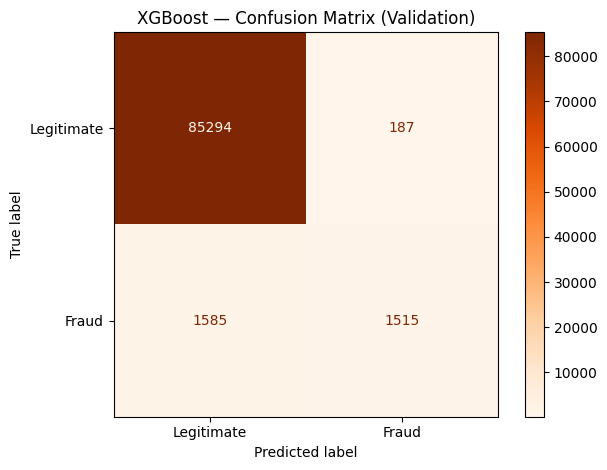

In [7]:
# Confusion matrix
cm = confusion_matrix(y_val, y_pred_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate', 'Fraud'])
disp.plot(cmap='Oranges')
plt.title('XGBoost — Confusion Matrix (Validation)')
plt.tight_layout()
plt.savefig('../results/figures/xgb_confusion_matrix.png', dpi=150)
plt.show()

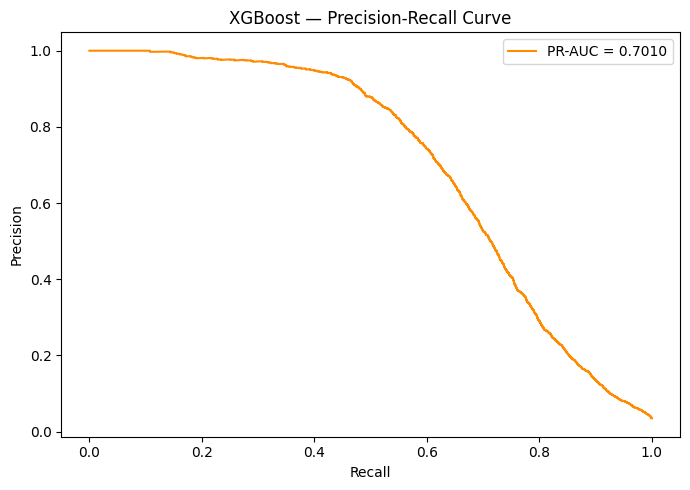

In [8]:
# Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_val, y_prob_val)
pr_auc = average_precision_score(y_val, y_prob_val)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, color='darkorange', label=f'PR-AUC = {pr_auc:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('XGBoost — Precision-Recall Curve')
plt.legend()
plt.tight_layout()
plt.savefig('../results/figures/xgb_pr_curve.png', dpi=150)
plt.show()

## 5. Final Evaluation on Test Set

The test set is only used once — after all tuning decisions are made.

In [9]:
y_pred_test = best_xgb.predict(X_test)
y_prob_test = best_xgb.predict_proba(X_test)[:, 1]

print('Final Results — Test Set')
print(classification_report(y_test, y_pred_test))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_test):.4f}')
print(f'PR-AUC:  {average_precision_score(y_test, y_prob_test):.4f}')

Final Results — Test Set
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     85482
           1       0.91      0.49      0.64      3099

    accuracy                           0.98     88581
   macro avg       0.94      0.74      0.81     88581
weighted avg       0.98      0.98      0.98     88581

ROC-AUC: 0.9404
PR-AUC:  0.7149


In [10]:
# Inference latency
start = time.time()
best_xgb.predict(X_test)
elapsed = time.time() - start
latency_ms = (elapsed / len(X_test)) * 1000

print(f'Total inference time: {elapsed:.2f}s')
print(f'Average latency per transaction: {latency_ms:.4f} ms')

Total inference time: 0.31s
Average latency per transaction: 0.0034 ms


## 6. Save Model and Results

In [11]:
import os
os.makedirs('../results', exist_ok=True)

joblib.dump(best_xgb, '../results/xgb_model.pkl')
pd.Series(y_prob_test, name='xgb_prob').to_csv('../results/xgb_test_probs.csv', index=False)

print('Model and predictions saved.')

Model and predictions saved.


## Summary

| Metric | Validation | Test |
|--------|-----------|------|
| PR-AUC | 0.7010 | 0.7149 |
| ROC-AUC | 0.9373 | 0.9404 |
| F1 (fraud) | 0.63 | 0.64 |
| Precision (fraud) | 0.89 | 0.91 |
| Recall (fraud) | 0.49 | 0.49 |
| Latency (ms/tx) | - | 0.0034 ms |

## Learning Curve

Same experiment as RF — training on increasing proportions of the data to see how performance scales.

In [4]:
from sklearn.metrics import average_precision_score

train_sizes = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]
train_pr_aucs = []
val_pr_aucs   = []

for size in train_sizes:
    n = int(len(X_train) * size)
    X_sub = X_train.iloc[:n]
    y_sub = y_train.iloc[:n]
    
    model_lc = XGBClassifier(
        learning_rate=0.1, max_depth=8, n_estimators=200,
        eval_metric='aucpr', random_state=42, n_jobs=-1
    )
    model_lc.fit(X_sub, y_sub)
    
    train_prob = model_lc.predict_proba(X_sub)[:, 1]
    val_prob   = model_lc.predict_proba(X_val)[:, 1]
    
    train_pr_aucs.append(average_precision_score(y_sub, train_prob))
    val_pr_aucs.append(average_precision_score(y_val,  val_prob))
    print(f'size {size:.0%} | train PR-AUC: {train_pr_aucs[-1]:.4f} | val PR-AUC: {val_pr_aucs[-1]:.4f}')

size 10% | train PR-AUC: 0.9331 | val PR-AUC: 0.6390
size 20% | train PR-AUC: 0.8903 | val PR-AUC: 0.6958
size 40% | train PR-AUC: 0.8641 | val PR-AUC: 0.7388
size 60% | train PR-AUC: 0.9847 | val PR-AUC: 0.7225
size 80% | train PR-AUC: 0.9973 | val PR-AUC: 0.7083
size 100% | train PR-AUC: 0.9989 | val PR-AUC: 0.7010


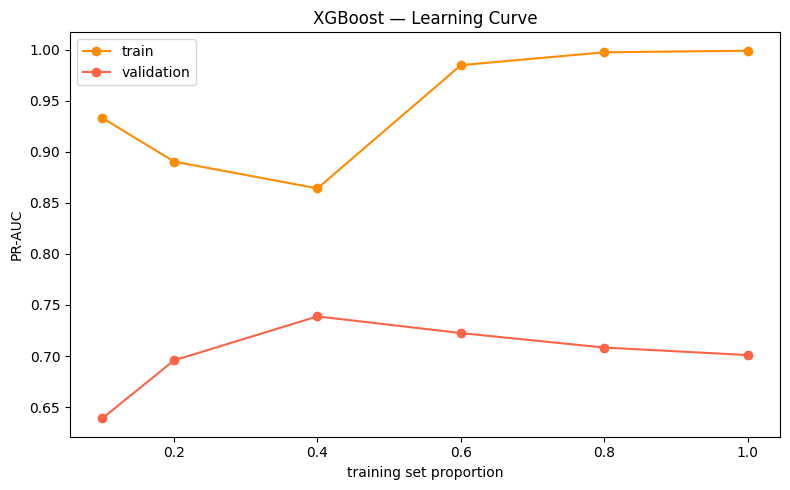

In [5]:
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_pr_aucs, 'o-', color='darkorange', label='train')
plt.plot(train_sizes, val_pr_aucs,   'o-', color='tomato',     label='validation')
plt.xlabel('training set proportion')
plt.ylabel('PR-AUC')
plt.title('XGBoost — Learning Curve')
plt.legend()
plt.tight_layout()
plt.savefig('../results/figures/xgb_learning_curve.png', dpi=150)
plt.show()